# Segmentation Visualization — ARTE_390

This notebook plots NSD (Net Squared Displacement, i.e. how far the bird is from their home in the Arctic/north) against time for ARTE_390, colored by which migration phase our system assigned to each point: southbound, wintering, or northbound.

Distance is relative to how far they are from their breeding grounds (home) in the North/Arctic. 

Run this after `pip install matplotlib` if you don't already have it installed.

In [1]:
import matplotlib.pyplot as plt 
import pandas as pd

from bird_dtw.species.arctic_tern.data import fetch_data, load_tracks
from bird_dtw.species.arctic_tern.segmentation.segmentation import segment_track, compute_nsd

In [2]:
raw = fetch_data()
tracks = load_tracks(raw)

bird_id = "ARTE_390"
track = tracks[bird_id]

print(f"{bird_id}: {len(track)} GPS fixes, {track['timestamp'].min()} to {track['timestamp'].max()}")

ARTE_390: 406 GPS fixes, 2007-08-20 00:11:00 to 2008-05-24 23:29:00


In [3]:
# Run the segmentation with our chosen final parameters
phases = segment_track(
    track,
    smooth_days=12,
    trend_days=12,
    flat_threshold_frac=0.08,
)

south = phases["southbound"]
winter = phases["wintering"]
north = phases["northbound"]

print(f"southbound: {len(south)} fixes, {south['timestamp'].min()} to {south['timestamp'].max()}")
print(f"wintering:  {len(winter)} fixes, {winter['timestamp'].min()} to {winter['timestamp'].max()}")
print(f"northbound: {len(north)} fixes, {north['timestamp'].min() if len(north) else 'EMPTY'} to {north['timestamp'].max() if len(north) else 'EMPTY'}")

DEBUG: winter_run indices = (159, 332)
DEBUG: south_run before cap = (47, 158), max_south_fixes=220
DEBUG: south_run after cap = (47, 158)
DEBUG: south_run spans real dates 2007-09-12 11:49:00 to 2007-11-23 23:31:00, index count=111
DEBUG: south_run with NO bridging = (47, 124)
DEBUG: no-bridge south_run spans real dates 2007-09-12 11:49:00 to 2007-11-06 23:19:00
southbound: 112 fixes, 2007-09-12 11:49:00 to 2007-11-23 23:31:00
wintering:  221 fixes, 2007-08-20 00:11:00 to 2008-04-16 11:42:00
northbound: 73 fixes, 2008-04-16 23:45:00 to 2008-05-24 23:29:00


In [4]:
# Compute NSD (distance-from-home, squared) for every point in the FULL track,
# so we can plot the whole year as one continuous line.
home_lat, home_lon = track.iloc[0][["lat", "lon"]]
nsd_full = compute_nsd(track, home_lat, home_lon)

# Label each row in the full track with its assigned phase, by matching timestamps
# against the three phase DataFrames segment_track() already produced.
phase_label = pd.Series("wintering", index=track.index)
phase_label[track["timestamp"].isin(south["timestamp"])] = "southbound"
phase_label[track["timestamp"].isin(north["timestamp"])] = "northbound"

plot_df = pd.DataFrame({
    "timestamp": track["timestamp"],
    "nsd": nsd_full,
    "phase": phase_label,
})

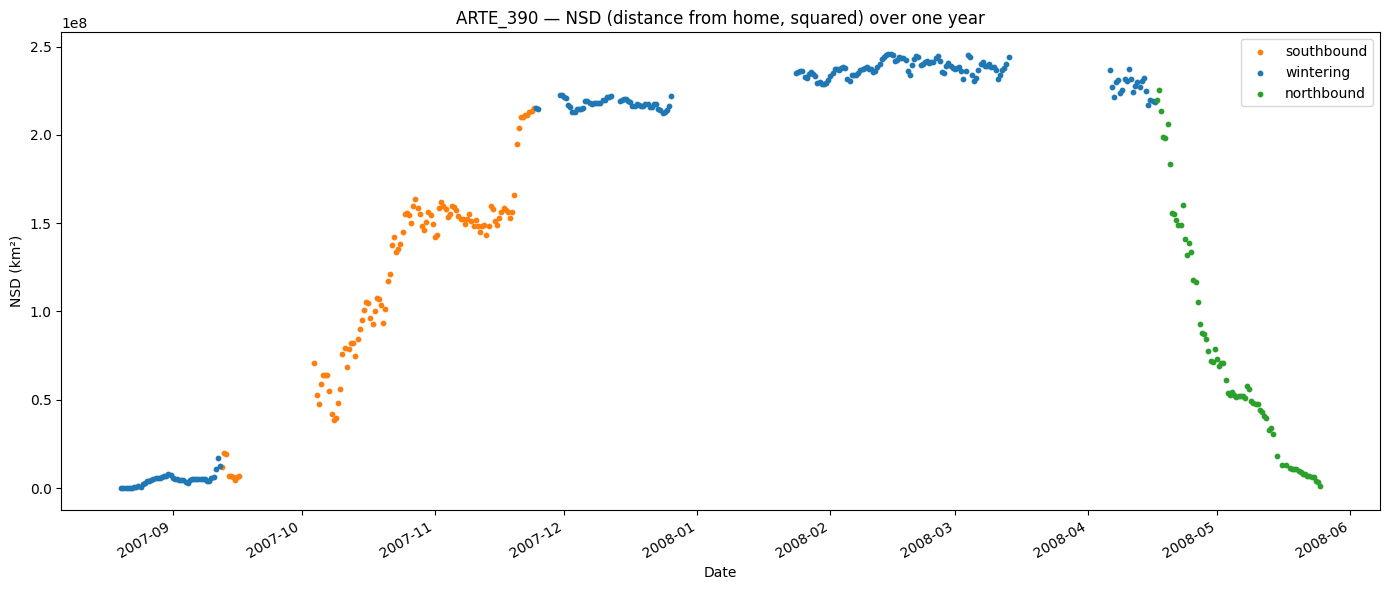

In [5]:
# Plot: one line for the whole year, colored dot-by-dot by phase
colors = {"southbound": "tab:orange", "wintering": "tab:blue", "northbound": "tab:green"}

fig, ax = plt.subplots(figsize=(14, 6))

for phase_name, color in colors.items():
    subset = plot_df[plot_df["phase"] == phase_name]
    ax.scatter(subset["timestamp"], subset["nsd"], s=10, color=color, label=phase_name)

ax.set_title(f"{bird_id} — NSD (distance from home, squared) over one year")
ax.set_xlabel("Date")
ax.set_ylabel("NSD (km²)")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## How to read this graph

- **Orange (southbound):** NSD should be rising — the bird is moving away from home (the Arctic), toward wintering grounds.
- **Blue (wintering):** NSD should be roughly flat and near its highest point — the bird has arrived and is staying far from home.
- **Green (northbound):** NSD should be falling — the bird is heading back home.

Note: a few points right at the very start of the year may show as blue even though the bird hasn't started migrating yet. That's a labeling quirk of this notebook's plotting code (anything not explicitly southbound/northbound defaults to "wintering" for display), not a bug in the real segmentation output.

If the colors don't line up cleanly with the shape of the curve, that's a sign this bird may need different parameters than the global default.